# **Problem Statement**

Predicting energy consumption in residential buildings is important for energy management, cost savings, and reducing environmental impact. Household appliances often account for a significant share of total electricity usage, and this usage is influenced by a mix of factors, indoor temperature and humidity across different rooms, outdoor weather conditions, and time-based patterns like hour of day or day of week.

# **Importing Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# **Loading the CSV**

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Data Sets/KAG_energydata_complete.csv')
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


**Checking how big the dataset is (rows x columns).**

In [ ]:
df.shape

(19735, 29)

**Looking at column names, data types and non-null counts**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

**Counting missing values per column**

In [ ]:
df.isnull().sum()

,0
date,0
Appliances,0
lights,0
T1,0
RH_1,0
T2,0
RH_2,0
T3,0
RH_3,0
T4,0


**Checking for duplicate rows.**

In [ ]:
df.duplicated().sum()

np.int64(0)

 **Summary Stats (mean, min, max, quartiles etc.) for every numeric column**

In [ ]:
df.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


# **Exploratory Data Analysis(EDA)**

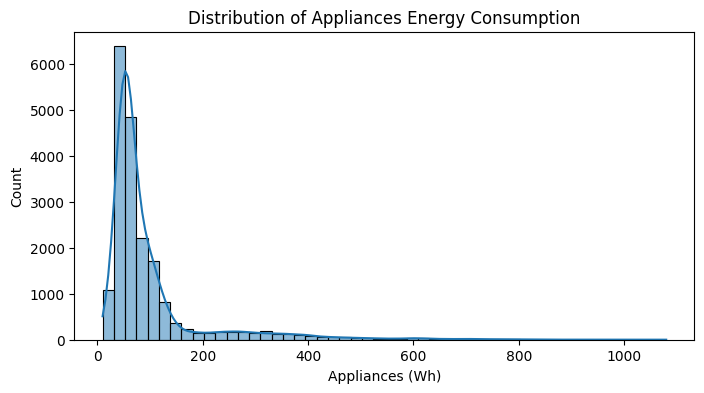

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['Appliances'], bins=50, kde=True)
plt.title('Distribution of Appliances Energy Consumption')
plt.xlabel('Appliances (Wh)')
plt.show()

Boxplot of Appliances to spot outliers visually.

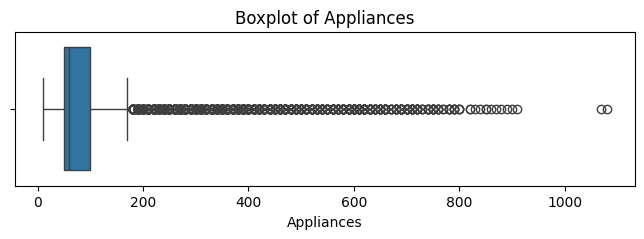

In [ ]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df['Appliances'])
plt.title('Boxplot of Appliances')
plt.show()

Correlation heatmap across all numeric columns - to see which features move together.

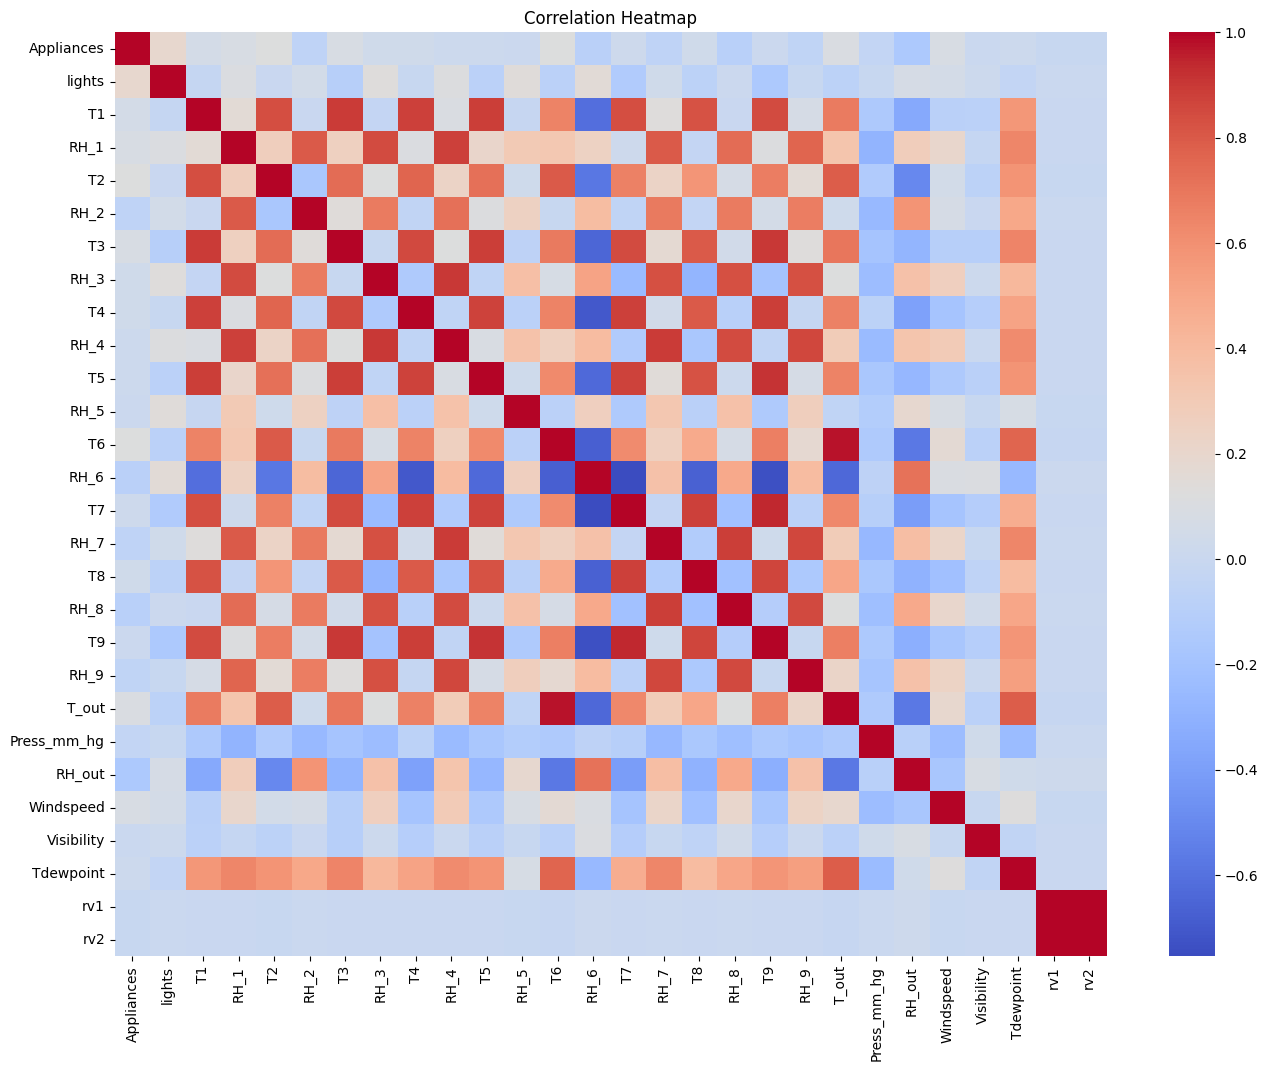

In [ ]:
plt.figure(figsize=(16,12))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()

Sorting all features by how correlated they are with Appliances

In [ ]:
target_corr = corr['Appliances'].sort_values(ascending=False)
target_corr

,Appliances
Appliances,1.000000
lights,0.197278
T2,0.120073
T6,0.117638
T_out,0.099155
Windspeed,0.087122
RH_1,0.086031
T3,0.085060
T1,0.055447
T4,0.040281


In [ ]:
df[['rv1', 'rv2', 'Appliances']].corr()

,rv1,rv2,Appliances
rv1,1.000000,1.000000,-0.011145
rv2,1.000000,1.000000,-0.011145
Appliances,-0.011145,-0.011145,1.000000


In [ ]:
df.dtypes

,0
date,object
Appliances,int64
lights,int64
T1,float64
RH_1,float64
T2,float64
RH_2,float64
T3,float64
RH_3,float64
T4,float64


Converting 'date' from text to an actual datetime type so I can pull hour/day info out of it.

In [7]:
df['date'] = pd.to_datetime(df['date'])

Dropping rv1 and rv2 since they're just random columns with no real relationship to Appliances.

In [8]:
df = df.drop(columns=['rv1', 'rv2'])

Detecting and removing outliers from the target variable (Appliances) using the Interquartile Range (IQR) method. This helps reduce the influence of extreme energy consumption values and can improve the model's prediction performance.

In [9]:
Q1 = df["Appliances"].quantile(0.25)
Q3 = df["Appliances"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Appliances"] >= lower) & (df["Appliances"] <= upper)]

Making new columns from the date: hour of day, day of week, whether it's a weekend, and month. These should help since energy use probably follows a daily/weekly pattern.

In [10]:
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df['month'] = df['date'].dt.month

Dropping the original date column now.

In [11]:
df = df.drop(columns=['date'])

 Quick shape check after all the cleaning/feature engineering to make sure nothing broke.

In [12]:
df.shape

(17597, 30)

# **Splitting into features (X) and target (y), then doing an 80/20 train-test split.**

In [13]:
X = df.drop(columns=['Appliances'])
y = df['Appliances']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

# **Double-checking the shapes of the train/test sets after splitting.**

In [14]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((14077, 29), (3520, 29), (14077,), (3520,))

# **Setting up the Random Forest model**

In [15]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    bootstrap=True,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_features='sqrt', n_jobs=-1, random_state=42)

# **Setting up the Decision Tree model**

In [16]:
dt_model = DecisionTreeRegressor(
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=15, min_samples_leaf=2, min_samples_split=5,
                      random_state=42)

# **Setting up the XGBoost model**

In [17]:
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    objective='reg:squarederror'
)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=-1, num_parallel_tree=None, ...)

# **Evaluation**

In [18]:
def evaluate_model(model, name):
    preds = model.predict(X_test)
    return {
        'Model': name,
        'R2': r2_score(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE': mean_absolute_error(y_test, preds)
    }

results = [
    evaluate_model(dt_model, 'Decision Tree'),
    evaluate_model(rf_model, 'Random Forest'),
    evaluate_model(xgb_model, 'XGBoost')
]

results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False).reset_index(drop=True)
print(results_df)

           Model        R2       RMSE        MAE
0  Random Forest  0.692174  16.061420  10.595767
1        XGBoost  0.631777  17.566564  11.860609
2  Decision Tree  0.551362  19.390053  12.719920


# **Choosing Best Model**
Random Forest gave the best results in all three evaluation metrics (R², RMSE, and MAE). XGBoost came in second, while the Decision Tree gave the weakest performance.
This is expected because a Decision Tree uses only one tree, so it can easily learn the noise in the data (overfitting). Random Forest combines many decision trees and averages their predictions, which makes it more accurate and stable. XGBoost also performs very well, but in this project it does not perform well.
Based on these results, Random Forest was chosen as the final model.

In [19]:
final_model = {'Decision Tree': dt_model, 'Random Forest': rf_model, 'XGBoost': xgb_model}[results_df.iloc[0]['Model']]

joblib.dump(final_model, 'model.pkl')
joblib.dump(X_train.columns.tolist(), 'features.pkl')

['features.pkl']